In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
plt.rcParams.update({'font.size': 12})
import seaborn as sns
import cmath
import math 
from numpy.linalg import inv
from utils_SS import *

plt.rcParams['xtick.labelsize'] = 30  # Set font size for x-axis tick labels
plt.rcParams['ytick.labelsize'] = 30  # Set font size for y-axis tick labels

def custom_plot_single(fig, ax1, 
                       x_lst, y_lst, label_lst, xlim, ylim, label,pltname,
                       color=['k','r','b','g','o','c','m','y'],
                       linestyle=['solid','dashed','solid','dashed','solid','dashed'],
                       markertype=[None,None,'o','^','o','^'],
                       fillstyle=['none','none','none','none','full','full'],
                       linewidth=20*[3],
                       markevery=[450,30,50,40,56,72,63,95],
                       show_legend=True,
                       plt_outside=False, y_logscale = False):
    
    fig.patch.set_facecolor('white')
    ax1.patch.set_facecolor('white')
    #color[len(x_lst)-1] = 'gray'
    for p in range(0, len(x_lst)):
        ax1.plot(x_lst[p], y_lst[p], color[p],
                 linewidth=linewidth[p],
                 linestyle=linestyle[p],
                 marker=markertype[p],
                 fillstyle=fillstyle[p],
                 markevery=markevery[p],
                 markersize=8,
                 label=label_lst[p])

    ax1.tick_params(which='minor', width=2, length=4, color='k')
    ax1.tick_params(which='major', width=2, length=8, color='k')

    #ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    #ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    if(show_legend):
        ax1.legend(prop={'size': 18},loc='best',shadow=True, frameon=False, bbox_to_anchor=(1.01,1.0))
    if (y_logscale):
        ax1.set_yscale('log')
    ax1.set_ylim(ylim[0],ylim[1])
    ax1.set_xlim(xlim[0],xlim[1])
    ax1.set_xlabel(label[0], fontsize=30)#, fontdict=dict(weight='bold'))
    ax1.set_ylabel(label[1], fontsize=30)#, fontdict=dict(weight='bold'))
    fontsize=30
    for tick in ax1.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)

    for tick in ax1.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for spine in ax1.spines.values():
        spine.set_linewidth(2)  # Increase the frame thickness             
    if(plt_outside==False):
        plt.savefig(pltname, bbox_inches = "tight")
    return plt,pltname

PrintFigures=True
PointCharge=True


In [2]:
import pandas as pd
folder_path = '../figures_exp/'
Fig1d = pd.read_csv(folder_path  + 'fig1d.csv', header=None)

Vgs_exp  = Fig1d[0].to_numpy()
Ids_exp  = Fig1d[1].to_numpy() 


In [26]:
#quantum of conductance
#https://physics.nist.gov/cgi-bin/cuu/Value?conqu2e2sh
#G_quantum=2e^2/h, q=1.602e-19, h = 6.62607e-34

G_quantum  = 7.748091729e-5 #[S] 

num_CNTs = 1
Vds = 0.1
CNT_spacing = 2.556e-3
micron = 1e-6
nano=1e-9

CNTs_per_micron = micron/CNT_spacing
pts_max  = 64

m=20
n=0
acc = 0.142e-9
gamma=2.5 #eV
Temp = 298.
Ef = -0.2 #eV

def get_radius(acc,m,n):
    return acc*(np.sqrt(3.)/(2*np.pi))*np.sqrt(m**2 + m*n + n**2)
    
R_cnt = get_radius(acc,m,n)
print('Radius of CNT (nm):', R_cnt/nano)

Eg_min = acc*gamma/R_cnt
print('bandgap, Eg_min/(eV):', Eg_min)

Radius of CNT (nm): 0.7828870314989447
bandgap, Eg_min/(eV): 0.45344984105855446


In [27]:
variable_occupation = []
foldername = [] 
label_str = []
Color = []
label_str.append(r'Experiment, $E_f=-1$')
Color.append('red')

rhop_3D = []
rhop_2D = []
foldername.append('../periodic/with_point_charge/no_charge/EfmDot2')
label_str.append(r'$E_f=-0.2$, $\rho_p=0$')
Color.append('k')
variable_occupation.append(False)
rhop_3D.append(0) # for base case of 0 trap
rhop_2D.append(0) # for base case of 0 trap


start_3D=1
foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot1')
label_str.append(r'(3D) $\rho_p = 0.1$ e/nm$^3$')
Color.append('b')
variable_occupation.append(True)
rhop_3D.append(0.1) 

foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot2')
label_str.append(r'(3D) $\rho_p = 0.2$ e/nm$^3$')
Color.append('b')
variable_occupation.append(True)
rhop_3D.append(0.2) 

foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot3')
label_str.append(r'(3D) $\rho_p = 0.3$ e/nm$^3$')
Color.append('b')
variable_occupation.append(True)
rhop_3D.append(0.3) 

foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot4')
label_str.append(r'(3D) $\rho_p = 0.4$ e/nm$^3$')
Color.append('b')
variable_occupation.append(True)
rhop_3D.append(0.4) 

foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot5')
label_str.append(r'(3D) $\rho_p = 0.5$ e/nm$^3$')
Color.append('b')
variable_occupation.append(True)
rhop_3D.append(0.5) 

foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot6')
label_str.append(r'(3D) $\rho_p = 0.6$ e/nm$^3$')
Color.append('b')
variable_occupation.append(True)
rhop_3D.append(0.6) 

foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot7')
label_str.append(r'(3D) $\rho_p = 0.7$ e/nm$^3$')
Color.append('cyan')
variable_occupation.append(True)
rhop_3D.append(0.7) 

end_3D=start_3D+7

foldername.append('../periodic/with_point_charge/density_variation_2D/rhoDot2')
label_str.append(r'(2D) $\rho_p = 0.2$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(0.2) 

foldername.append('../periodic/with_point_charge/density_variation_2D/rhoDot4')
label_str.append(r'(2D) $\rho_p = 0.4$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(0.4)

foldername.append('../periodic/with_point_charge/density_variation_2D/rhoDot6')
label_str.append(r'(2D) $\rho_p = 0.6$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(0.6)

foldername.append('../periodic/with_point_charge/density_variation_2D/rhoDot8')
label_str.append(r'(2D) $\rho_p = 0.8$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(0.8)

foldername.append('../periodic/with_point_charge/density_variation_2D/rho1')
label_str.append(r'(2D) $\rho_p = 1$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(1)

foldername.append('../periodic/with_point_charge/density_variation_2D/rho1Dot2')
label_str.append(r'(2D) $\rho_p = 1.2$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(1.2)

foldername.append('../periodic/with_point_charge/density_variation_2D/rho1Dot4')
label_str.append(r'(2D) $\rho_p = 1.4$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(1.4)

foldername.append('../periodic/with_point_charge/density_variation_2D/rho1Dot6')
label_str.append(r'(2D) $\rho_p = 1.6$ e/nm$^2$')
Color.append('yellow')
variable_occupation.append(True)
rhop_2D.append(1.6)

end_2D  = end_3D+ 8

num_labels=np.size(label_str)
num_folders=np.size(foldername)
rhop_3D = np.array(rhop_3D)
rhop_2D = np.array(rhop_2D)

print('start_3D', start_3D)
print('end_3D', end_3D)
print('end_2D', end_2D)

print('num_labels', num_labels)
print('num_folders', num_folders)

start_3D 1
end_3D 8
end_2D 16
num_labels 17
num_folders 16


In [28]:
num_folders=np.size(foldername)
Vgs =  np.zeros((num_folders, pts_max),dtype=float)
G   = np.zeros((num_folders, pts_max),dtype=float)
Ids_appx = np.zeros((num_folders, pts_max),dtype=float)
pts = np.zeros(num_folders,dtype=int)
#pts[:] = pts_max

In [29]:
for folder in range(num_folders):
    file_path = f"{foldername[folder]}/negf/NS_1/I.dat"
    print(str(folder) +  str(file_path))

    data = np.loadtxt(file_path, skiprows=1, usecols=(2, 7))  # Vgs = col[2], G = col[7]

    vgs_arr = np.array(data[:, 0])
    g_arr = np.array(data[:, 1])

    pts[folder] = len(vgs_arr)
    Vgs[folder][:pts[folder]] = vgs_arr
    G[folder][:pts[folder]] = g_arr
    Ids_appx[folder] =  G[folder]*G_quantum*Vds/CNT_spacing

0../periodic/with_point_charge/no_charge/EfmDot2/negf/NS_1/I.dat
1../periodic/with_point_charge/density_variation_3D/rhoDot1/negf/NS_1/I.dat
2../periodic/with_point_charge/density_variation_3D/rhoDot2/negf/NS_1/I.dat
3../periodic/with_point_charge/density_variation_3D/rhoDot3/negf/NS_1/I.dat
4../periodic/with_point_charge/density_variation_3D/rhoDot4/negf/NS_1/I.dat
5../periodic/with_point_charge/density_variation_3D/rhoDot5/negf/NS_1/I.dat
6../periodic/with_point_charge/density_variation_3D/rhoDot6/negf/NS_1/I.dat
7../periodic/with_point_charge/density_variation_3D/rhoDot7/negf/NS_1/I.dat
8../periodic/with_point_charge/density_variation_2D/rhoDot2/negf/NS_1/I.dat
9../periodic/with_point_charge/density_variation_2D/rhoDot4/negf/NS_1/I.dat
10../periodic/with_point_charge/density_variation_2D/rhoDot6/negf/NS_1/I.dat
11../periodic/with_point_charge/density_variation_2D/rhoDot8/negf/NS_1/I.dat
12../periodic/with_point_charge/density_variation_2D/rho1/negf/NS_1/I.dat
13../periodic/with_poin

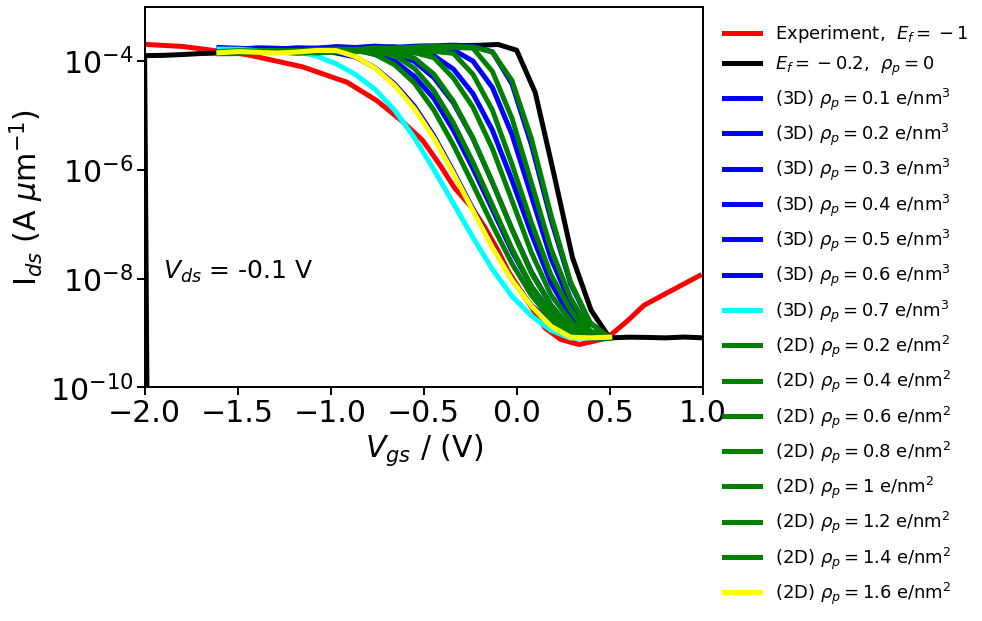

In [30]:
if(PrintFigures): 
    fig, ax = plt.subplots(1,1)
    fig.set_size_inches(10,7)    
    plt,pltname = custom_plot_single(fig,ax,
                                     [Vgs_exp] + [Vgs[0]] + [(Vgs[f][:pts[f]]) for f in range(start_3D, end_3D)]
                                     + [(Vgs[f][:pts[f]]) for f in range(end_3D, end_2D)], 
                                     [Ids_exp] + [Ids_appx[0]] + [Ids_appx[f][:pts[f]] for f in range(start_3D, end_3D)]
                                     + [Ids_appx[f][:pts[f]] for f in range(end_3D, end_2D)],
                                     [', '.join(label_str[folder].split(',')) for folder in range(num_labels)],
                                     [-2, 1],
                                     [1e-10,1e-3],
                                     [r'$V_{gs}$ / (V)',
                                      r'I$_{ds}$ (A $\mu$m$^{-1}$)'],
                                     'G_3D_2D_all.png',
                                     color=Color,
                                     linestyle=['solid']*num_labels,
                                     markertype=[None]*num_labels,
                                     markevery=[1]*num_labels,
                                     linewidth=[5]*num_labels,
                                     fillstyle=['none']*num_labels,                                     
                       show_legend=True,
                       plt_outside=True, y_logscale=True) 
    plt.text(-1.9,1e-8, r'$V_{ds}$ = -0.1 V', fontsize=25, color='k')
    
    plt.savefig(pltname, bbox_inches = "tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')
   

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_all_charges(plt, foldername, variable_occupation, label_str, Color):
    all_Vgs_values = []
    all_total_charge_values = []
    all_fractional_active_charge_values = []
    
    for i, folder in enumerate(foldername):
        #print(i,folder,variable_occupation[i])
        if variable_occupation[i]:
            filename = folder + '/point_charge/total_charge_vs_step.dat'
            print(filename)
            steps = []
            Vgs_values = []
            total_charge_values = []
            fractional_active_charge_values = []
            
            with open(filename, 'r') as file:
                lines = file.readlines()[1:]  # Skip the header
                current_step = None
                
                for line in lines:
                    cols = line.split()
                    #print(cols) #for debugging
                    step = int(cols[0])
                    Vgs = float(cols[2])
                    total_charge = float(cols[4])
                    fractional_active_charge = float(cols[5])
                    
                    # Check if the step has changed
                    if step != current_step:
                        if current_step is not None:
                            # Store the last entry before the step change
                            Vgs_values.append(last_Vgs)
                            total_charge_values.append(last_total_charge)
                            fractional_active_charge_values.append(last_fractional_active_charge)
                        current_step = step
                    
                    # Store the last values in the current step
                    last_Vgs = Vgs
                    last_total_charge = total_charge
                    last_fractional_active_charge = fractional_active_charge
                
                # Append the last set of values after the loop ends
                Vgs_values.append(last_Vgs)
                total_charge_values.append(last_total_charge)
                fractional_active_charge_values.append(last_fractional_active_charge)
            
            all_Vgs_values.append(Vgs_values)
            all_total_charge_values.append(total_charge_values)
            all_fractional_active_charge_values.append(fractional_active_charge_values)

    return np.array(all_Vgs_values), np.array(all_total_charge_values), np.array(all_fractional_active_charge_values)

In [32]:
all_Vgs_values, all_total_charge_values, all_fractional_active_charge_values = plot_all_charges(plt, foldername, variable_occupation, label_str, Color)

../periodic/with_point_charge/density_variation_3D/rhoDot1/point_charge/total_charge_vs_step.dat
../periodic/with_point_charge/density_variation_3D/rhoDot2/point_charge/total_charge_vs_step.dat
../periodic/with_point_charge/density_variation_3D/rhoDot3/point_charge/total_charge_vs_step.dat
../periodic/with_point_charge/density_variation_3D/rhoDot4/point_charge/total_charge_vs_step.dat
../periodic/with_point_charge/density_variation_3D/rhoDot5/point_charge/total_charge_vs_step.dat
../periodic/with_point_charge/density_variation_3D/rhoDot6/point_charge/total_charge_vs_step.dat
../periodic/with_point_charge/density_variation_3D/rhoDot7/point_charge/total_charge_vs_step.dat
../periodic/with_point_charge/density_variation_2D/rhoDot2/point_charge/total_charge_vs_step.dat
../periodic/with_point_charge/density_variation_2D/rhoDot4/point_charge/total_charge_vs_step.dat
../periodic/with_point_charge/density_variation_2D/rhoDot6/point_charge/total_charge_vs_step.dat
../periodic/with_point_charge/

In [33]:
total_charge_3D = all_total_charge_values[start_3D-1:end_3D-1]
total_charge_2D = all_total_charge_values[end_3D-1:end_2D-1]
fractional_charge_3D = all_fractional_active_charge_values[start_3D-1:end_3D-1]
fractional_charge_2D = all_fractional_active_charge_values[end_3D-1:end_2D-1]
np.shape(total_charge_3D)

(7, 21)

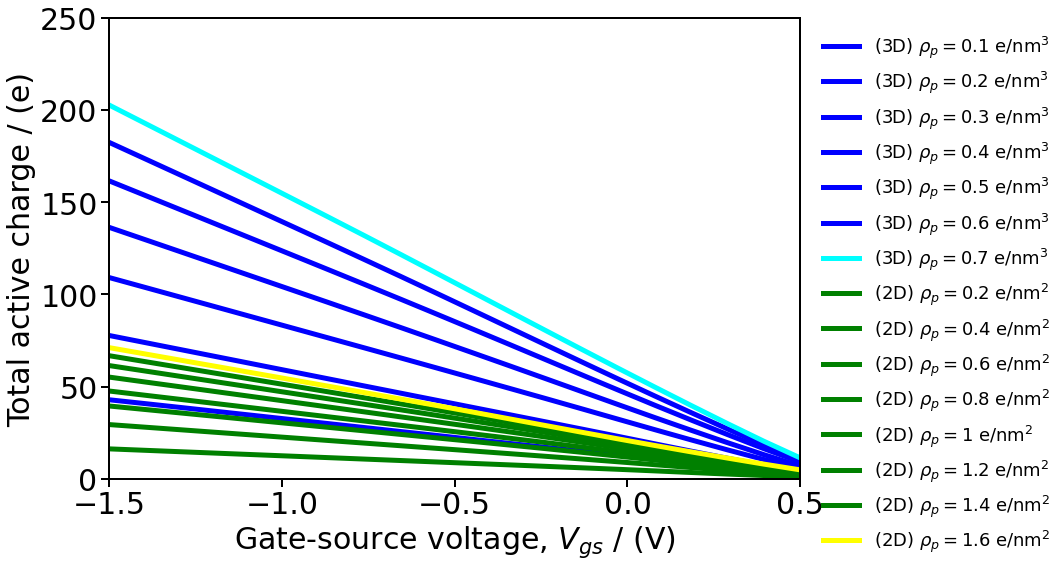

In [34]:
if PrintFigures: 
    fig = plt.figure(figsize=(12,8))
    ax = fig.add_axes([0.18,0.15,0.8,0.8])

    plt,pltname = custom_plot_single(fig, ax,
        x_lst=[(Vgs[f][:pts[f]]) for f in range(start_3D, end_3D)] + [(Vgs[f][:pts[f]]) for f in range(end_3D, end_2D)],
        y_lst=[total_charge_3D[f][:pts[f]] for f in range(np.shape(total_charge_3D)[0])] + [total_charge_2D[f][:pts[f]] for f in range(np.shape(total_charge_2D)[0])],
        label_lst=[', '.join(label_str[folder].split(',')) for folder in range(2,num_labels)],                            
        xlim=[-1.5, 0.5],
        ylim=[0, 250],
        label=['Gate-source voltage, $V_{gs}$ / (V)', 'Total active charge / (e)'],
        pltname='total_charge_3D_2D_all.png',
        color=Color[2:],
        linestyle=[None]*num_labels,
        markertype=[None]*num_labels,
        markevery=[1]*num_labels,
        linewidth=[5]*num_labels,
        fillstyle=['none']*num_labels
    )
    # Adding shaded regions (stddev)
    ax.set_xticks(np.arange(-1.5, 0.6, 0.5))  # X-axis ticks from -1.5 to 0.5 with a step of 0.5
    plt.savefig(pltname, bbox_inches="tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')

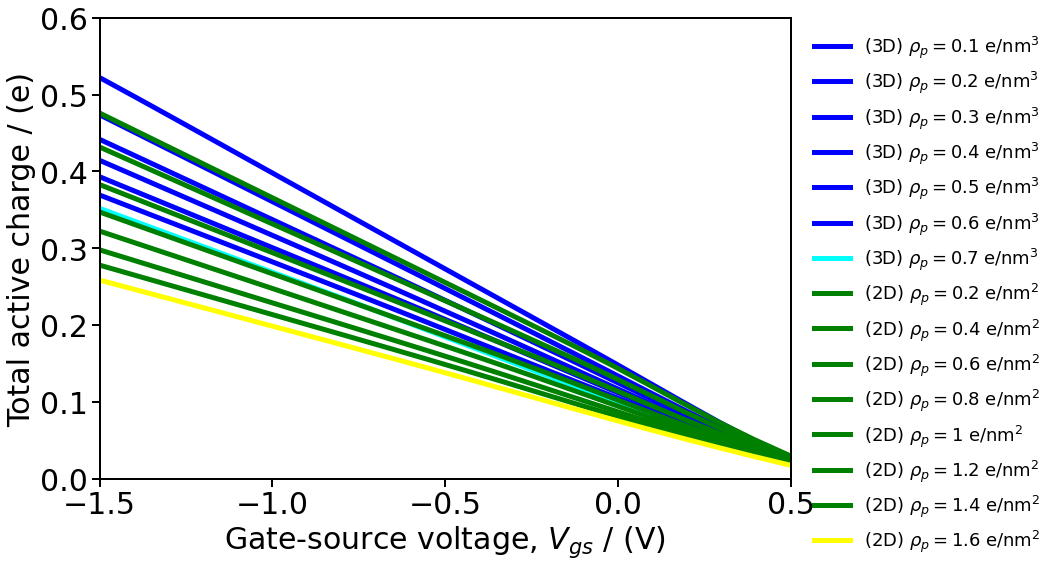

In [35]:
if PrintFigures: 
    fig = plt.figure(figsize=(12,8))
    ax = fig.add_axes([0.18,0.15,0.8,0.8])

    plt,pltname = custom_plot_single(fig, ax,
        x_lst=[(Vgs[f][:pts[f]]) for f in range(start_3D, end_3D)] + [(Vgs[f][:pts[f]]) for f in range(end_3D, end_2D)],
        y_lst=[fractional_charge_3D[f][:pts[f]] for f in range(np.shape(fractional_charge_3D)[0])] + [fractional_charge_2D[f][:pts[f]] for f in range(np.shape(fractional_charge_2D)[0])],
        label_lst=[', '.join(label_str[folder].split(',')) for folder in range(2,num_labels)],                            
        xlim=[-1.5, 0.5],
        ylim=[0, 0.6],
        label=['Gate-source voltage, $V_{gs}$ / (V)', 'Total active charge / (e)'],
        pltname='total_fractional_charge_3D_2D_all.png',
        color=Color[2:],
        linestyle=[None]*num_labels,
        markertype=[None]*num_labels,
        markevery=[1]*num_labels,
        linewidth=[5]*num_labels,
        fillstyle=['none']*num_labels
    )
    # Adding shaded regions (stddev)
    ax.set_xticks(np.arange(-1.5, 0.6, 0.5))  # X-axis ticks from -1.5 to 0.5 with a step of 0.5
    plt.savefig(pltname, bbox_inches="tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')

# Compute SS and ON current (per micron)

### First read band structure and find at what voltage is the band edge in the channel kT and 4kT away from the Fermi level.

In [36]:
from scipy.interpolate import interp1d
from scipy.optimize import fsolve

num_rings=1664
E_f = -0.2 #eV
Scaling_Factor = Vds*G_quantum*CNTs_per_micron

In [37]:
print(f"num_folders: {num_folders}, pts_max: {pts_max}, num_rings: {num_rings}")
Y =  np.zeros((num_folders,pts_max,num_rings),dtype=float)
Qout  = np.zeros((num_folders,pts_max,num_rings),dtype=float)
U     = np.zeros((num_folders,pts_max,num_rings),dtype=float)
Ev  = np.zeros((num_folders,pts_max,num_rings),dtype=float)
Ec  = np.zeros((num_folders,pts_max,num_rings),dtype=float)

num_folders: 16, pts_max: 64, num_rings: 1664


In [38]:
for folder in range(num_folders):
    path = foldername[folder] + '/negf/NS_1/step'
    print(f"folder: {folder}, path: {path}")
    
    for f in range(pts[folder]):
        s=f
        fileQout = open(path+"%04d_Qout.dat"%(s))
        #print('fileQout',fileQout)
        lst = []
        counter=0
        for line in fileQout:    
            if (counter > 0 and counter < num_rings+1):
                lst += [line.split()]
            counter  = counter + 1
        y = [x[0] for x in lst]
        qout = [x[1] for x in lst]
        Y[folder][f] = np.asfarray(y)
        Qout[folder][f] = np.asfarray(qout)
        
        fileU = open(path+"%04d_U.dat"%(s))
        lst = []
        counter=0
        for line in fileU:    
            if (counter > -1 and counter < num_rings+1):
                lst += [line.split()]
            counter  = counter + 1
        u = [x[2] for x in lst]
        U[folder][f] = np.asfarray(u)
        
        # fileNorm = open(path+"%04d_norm.dat"%(s))
        # lst = []
        # counter=0
        # for line in fileNorm:    
        #     if (counter > 0 and counter < num_rings+1):
        #         lst += [line.split()]
        #     counter  = counter + 1
        # #print(counter)
        # norm = [x[1] for x in lst]
        # Norm[folder][f] = np.asfarray(norm)

Ev = -Eg_min/2. + U
Ec = Eg_min/2. + U

folder: 0, path: ../periodic/with_point_charge/no_charge/EfmDot2/negf/NS_1/step
folder: 1, path: ../periodic/with_point_charge/density_variation_3D/rhoDot1/negf/NS_1/step
folder: 2, path: ../periodic/with_point_charge/density_variation_3D/rhoDot2/negf/NS_1/step
folder: 3, path: ../periodic/with_point_charge/density_variation_3D/rhoDot3/negf/NS_1/step
folder: 4, path: ../periodic/with_point_charge/density_variation_3D/rhoDot4/negf/NS_1/step
folder: 5, path: ../periodic/with_point_charge/density_variation_3D/rhoDot5/negf/NS_1/step
folder: 6, path: ../periodic/with_point_charge/density_variation_3D/rhoDot6/negf/NS_1/step
folder: 7, path: ../periodic/with_point_charge/density_variation_3D/rhoDot7/negf/NS_1/step
folder: 8, path: ../periodic/with_point_charge/density_variation_2D/rhoDot2/negf/NS_1/step
folder: 9, path: ../periodic/with_point_charge/density_variation_2D/rhoDot4/negf/NS_1/step
folder: 10, path: ../periodic/with_point_charge/density_variation_2D/rhoDot6/negf/NS_1/step
folder: 1

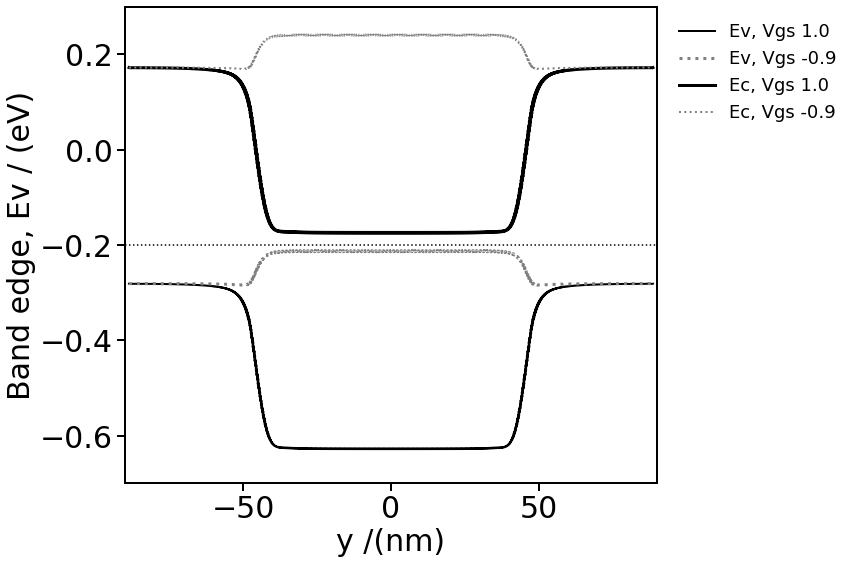

In [39]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(12,8)


if(PrintFigures):
    f=0 #folder
    i=0 #step 1 to plot bandstructure at
    j=19 # step 2 to plot bandstructure at
    delta=4 
    plt2,pltname = custom_plot_single(fig, ax,
                                     [Y[f][i], Y[f][j],Y[f][i], Y[f][j]], 
                                     [Ev[f][i], Ev[f][j],Ec[f][i], Ec[f][j]],
                                     [r'Ev, Vgs %.1f'%(Vgs[f][i]),r'Ev, Vgs %.1f'%(Vgs[f][j]),
                                      r'Ec, Vgs %.1f'%(Vgs[f][i]),r'Ec, Vgs %.1f'%(Vgs[f][j])],
                                     [-90,90],
                                     [-0.7,0.3],
                                     [r'y /(nm)',
                                      r'Band edge, Ev / (eV)'],
                                     'Ev.png',
                                     ['k','gray','k','gray','b'],
                                     linestyle=['solid','dotted','solid','dotted','solid','solid'],
                                     markertype=[None]*5,
                                     markevery=[1,1,1,1,1],
                                     linewidth=[2,3,3,2,2],
                       show_legend=True,
                       plt_outside=True, y_logscale=False)
    ax.axhline(y = E_f, color = 'k', linestyle = 'dotted')

fig.tight_layout()
#fig.savefig(filename, dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')


3D stats:

folder: 1 , counter:  1
label: (3D) $\rho_p = 0.1$ e/nm$^3$
figIDi/j:  0 0
ON current / (1e-4 μA): 1.4060331106953274
Vgs where barrier is  8 kT: 0.11697546609776456
Vgs where barrier is  12 kT: 0.2524228369725824
Vgs where phonon-tunneling barrier is 0.2 eV: 0.17526551340320937
	SS (mV/decade): 82.3

folder: 2 , counter:  2
label: (3D) $\rho_p = 0.2$ e/nm$^3$
figIDi/j:  1 0
ON current / (1e-4 μA): 1.5306300646613238
Vgs where barrier is  8 kT: 0.04563477203148914
Vgs where barrier is  12 kT: 0.1994047835301241
Vgs where phonon-tunneling barrier is 0.2 eV: 0.11487032720006662
	SS (mV/decade): 94.4

folder: 3 , counter:  3
label: (3D) $\rho_p = 0.3$ e/nm$^3$
figIDi/j:  2 0
ON current / (1e-4 μA): 1.598653217399493
Vgs where barrier is  8 kT: -0.003242299794661181
Vgs where barrier is  12 kT: 0.1651831084341358
Vgs where phonon-tunneling barrier is 0.2 eV: 0.07049486652977414
	SS (mV/decade): 111.0

folder: 4 , counter:  4
label: (3D) $\rho_p = 0.4$ e/nm$^3$
figIDi/j:  0 1
ON

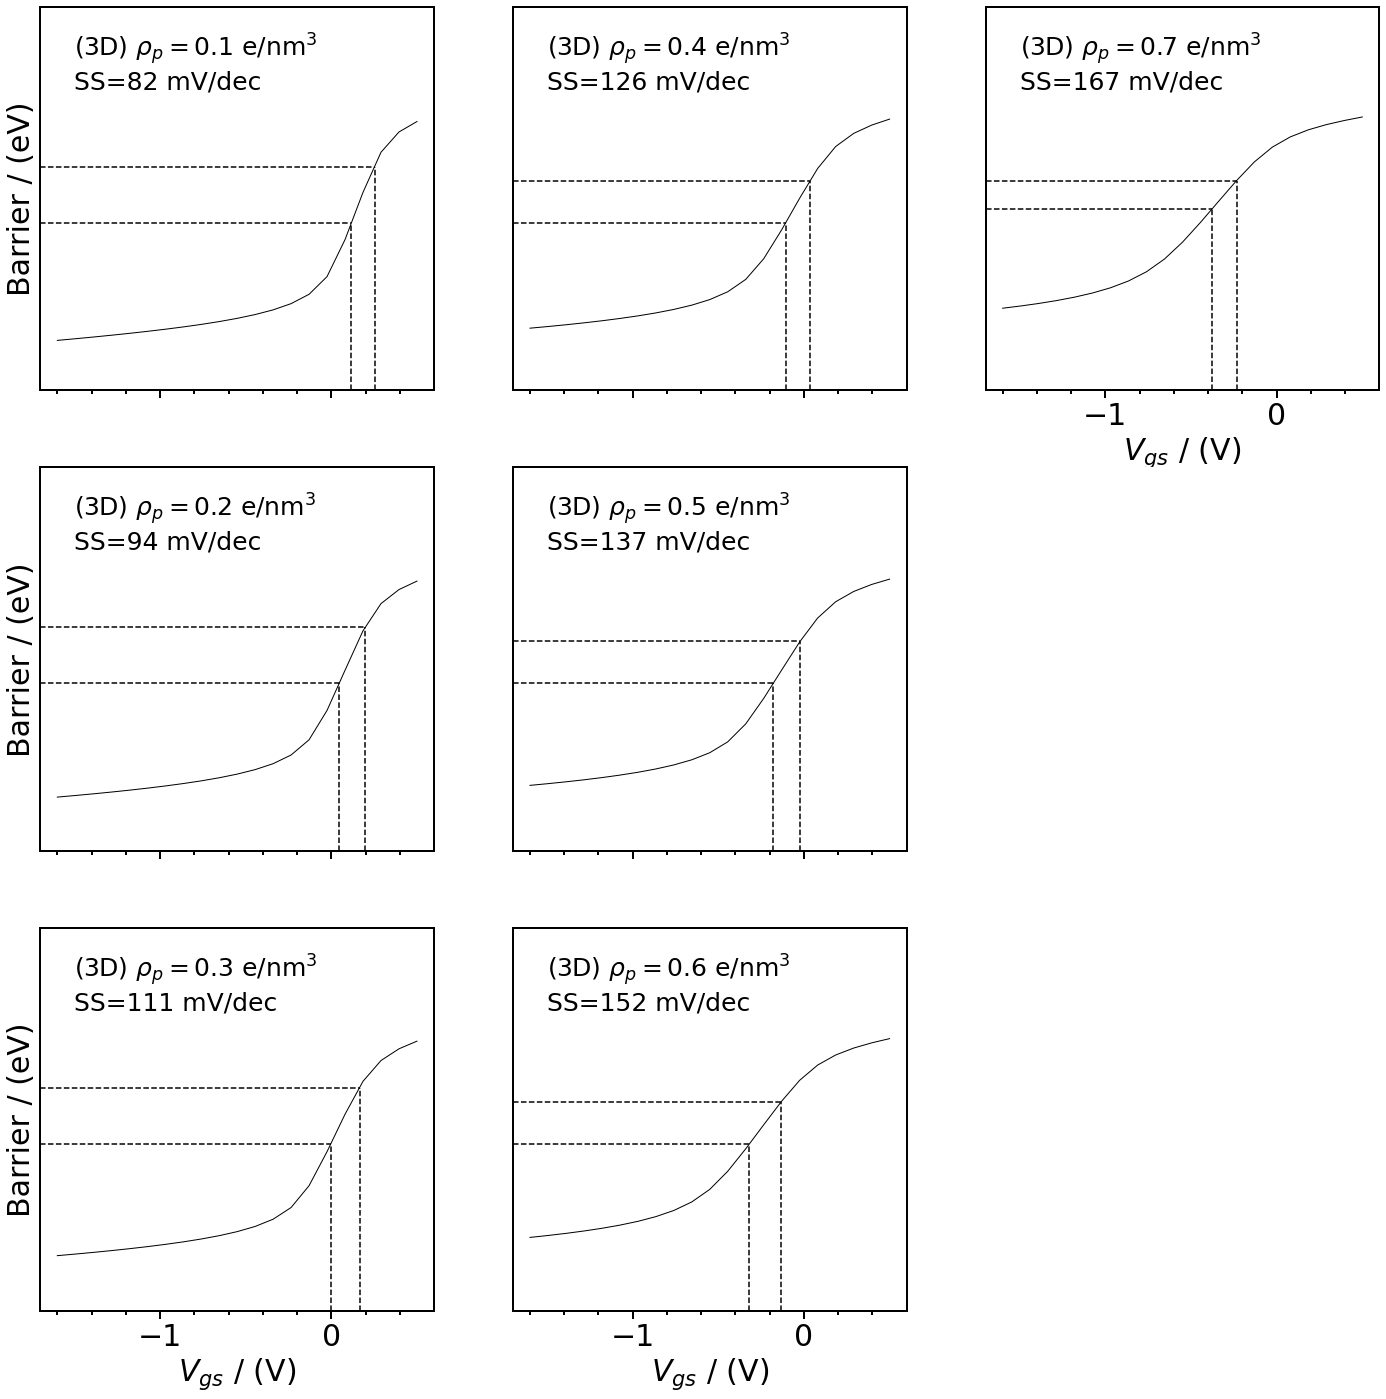

In [112]:
print('\n3D stats:')
fig, ax = plt.subplots(3, 3, figsize=(24, 24), sharex=False, sharey=True)

# Ensure consistent Y sharing across first column
ax[2, 0].get_shared_y_axes().join(ax[0, 0], ax[1, 0], ax[2, 0])

counter = 1  # Start from 0 if you're indexing arrays like I_ON_3D[counter]

for folder in range(start_3D, end_3D):  # Will loop from 1 to 6
    print('\nfolder:', folder, ', counter: ', counter)
    print('label:', label_str[folder+1])
    
    fig_idx_i = (folder - start_3D) % 3
    fig_idx_j = (folder - start_3D) // 3
    print('figIDi/j: ', fig_idx_i, fig_idx_j)

    ax_ij = ax[fig_idx_i, fig_idx_j]

    I_ON_3D[counter] = Scaling_Factor * G[folder][pts[folder]-1]
    print('ON current / (1e-4 μA):', I_ON_3D[counter] * 1e10)

    # Choose barrier regions
    if fig_idx_j==0 and fig_idx_i < 3:
        a, b = 8, 12
    elif fig_idx_j==1 and fig_idx_i < 2:
        a, b= 8, 11
    elif fig_idx_j==1 and fig_idx_i==2:
        a, b= 8, 11
    elif fig_idx_j==2:
        a, b = 9, 11

    vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(
        U[folder][:pts[folder]],
        Vgs[folder][:pts[folder]],
        fig, ax_ij,
        Ef=Ef, a=a, b=b, Print=True
    )

    # Remove spines for unused panels
    if fig_idx_j == 2 and fig_idx_i > 0:
        for spine in ax_ij.spines.values():
            spine.set_visible(False)
        ax_ij.set_xticks([])
        ax_ij.set_yticks([])
        ax_ij.set_xticklabels([])
        ax_ij.set_yticklabels([])

    SS_3D[counter] = compute_SS(
        Vgs[folder][:pts[folder]],
        G[folder][:pts[folder]],
        vgs_at_akT, vgs_at_bkT, True
    )

    ax_ij.text(-1.5, 0.45, f"{label_str[folder+1]}\nSS={int(SS_3D[counter])} mV/dec",
               fontsize=25, color='k')
        
    # Remove axis labels where needed
    if fig_idx_i < 2 and fig_idx_j < 2:
        ax_ij.set_xlabel('')
        ax_ij.set_xticklabels('')
    if fig_idx_j > 0:
        ax_ij.set_ylabel('')
        ax_ij.set_yticklabels('') 

    counter += 1

# Explicitly clear axis labels and ticks for known empty subplots
for (i, j) in [(1, 2), (2, 2)]:
    ax[i, j].set_xticks([])
    ax[i, j].set_yticks([])
    ax[i, j].set_xticklabels([])
    ax[i, j].set_yticklabels([])
    ax[i, j].set_xlabel('')
    ax[i, j].set_ylabel('')
    for spine in ax[i, j].spines.values():
        spine.set_visible(False)        
plt.savefig('SS_computation_3D_density_variation.png', bbox_inches = "tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')

print('SS_3D',(SS_3D))


2D stats:

folder: 8 , counter:  1
label: (2D) $\rho_p = 0.2$ e/nm$^2$
figIDi/j:  0 0
ON current / (1e-4 μA): 1.3895820567777677
Vgs where barrier is  8 kT: 0.1165587883572697
Vgs where barrier is  12 kT: 0.25149577288949804
Vgs where phonon-tunneling barrier is 0.2 eV: 0.17492801662583737
	SS (mV/decade): 79.7

folder: 9 , counter:  2
label: (2D) $\rho_p = 0.4$ e/nm$^2$
figIDi/j:  1 0
ON current / (1e-4 μA): 1.4197468692954822
Vgs where barrier is  8 kT: 0.051340089627101945
Vgs where barrier is  12 kT: 0.2032410204120894
Vgs where phonon-tunneling barrier is 0.2 eV: 0.11975082246862434
	SS (mV/decade): 89.7

folder: 10 , counter:  3
label: (2D) $\rho_p = 0.6$ e/nm$^2$
figIDi/j:  2 0
ON current / (1e-4 μA): 1.361132979752468
Vgs where barrier is  8 kT: -0.017889952296660787
Vgs where barrier is  12 kT: 0.15192328425592128
Vgs where phonon-tunneling barrier is 0.2 eV: 0.05752632684287902
	SS (mV/decade): 102.1

folder: 11 , counter:  4
label: (2D) $\rho_p = 0.8$ e/nm$^2$
figIDi/j:  0 

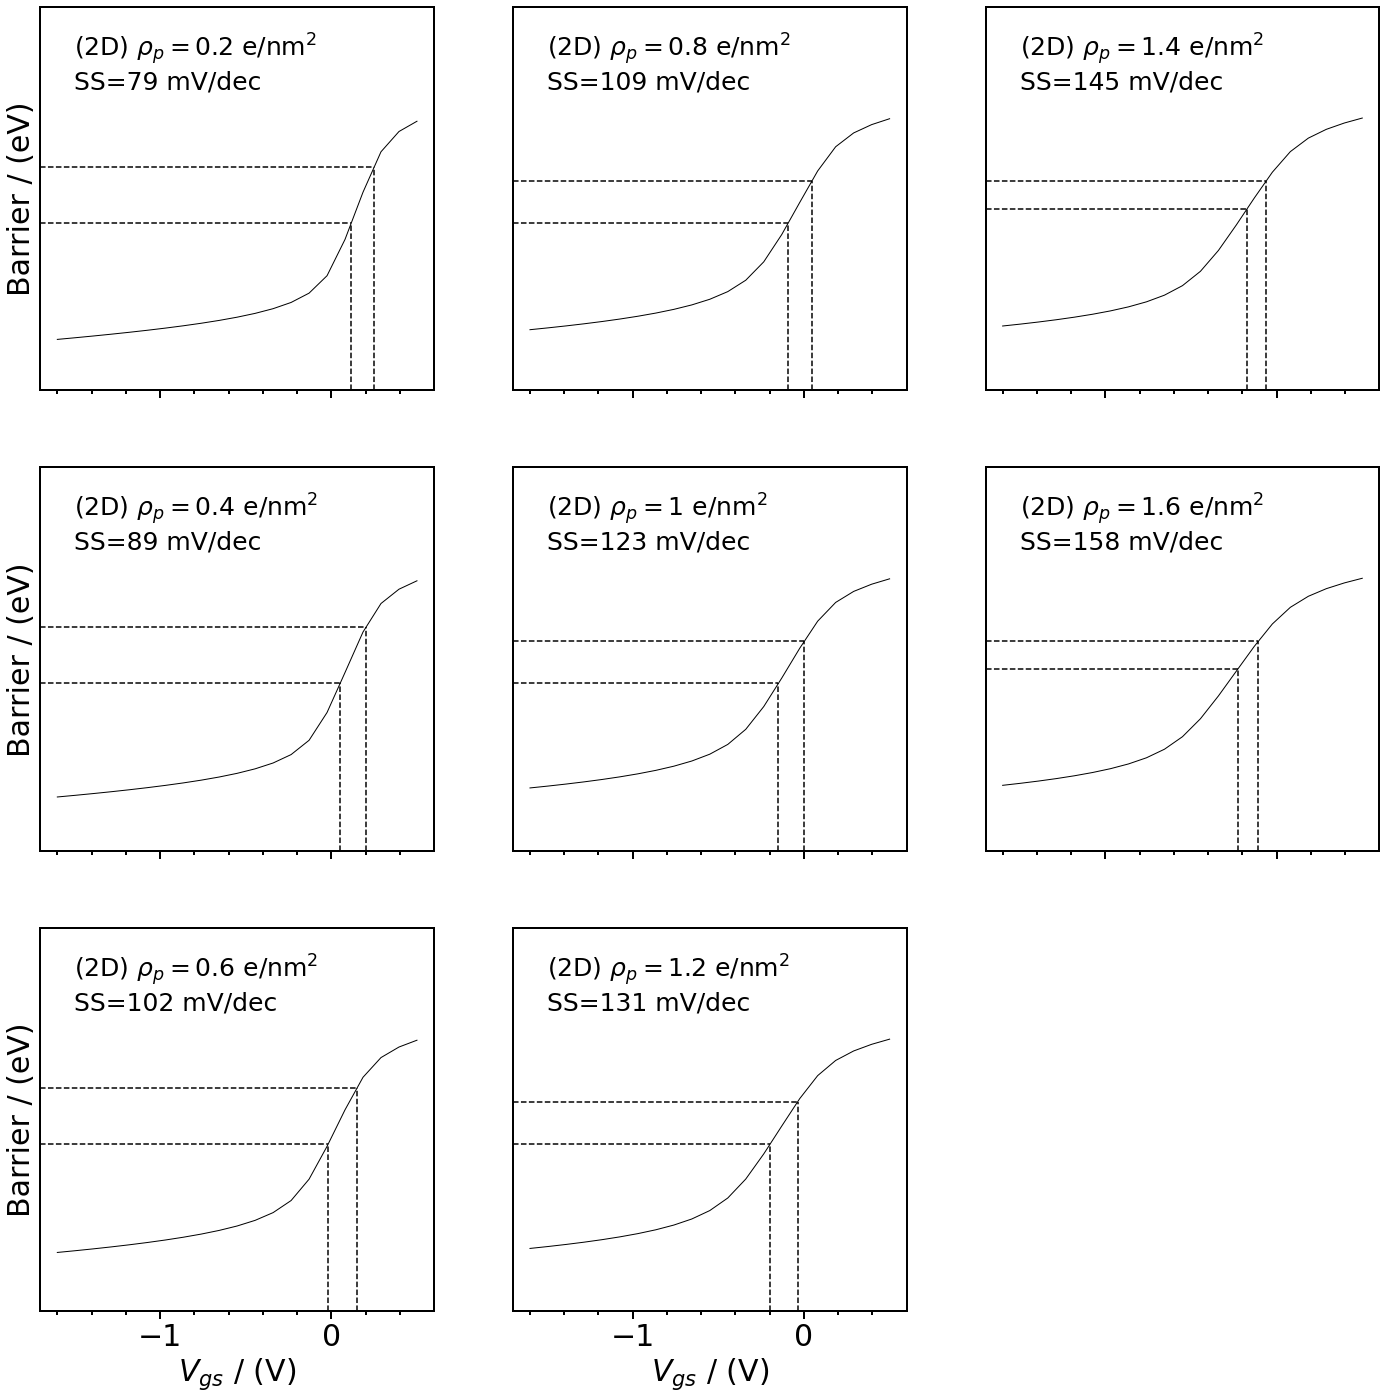

In [121]:
print('\n2D stats:')
fig, ax = plt.subplots(3, 3, figsize=(24, 24), sharex=False, sharey=True)

# Ensure consistent Y sharing across first column
ax[2, 0].get_shared_y_axes().join(ax[0, 0], ax[1, 0], ax[2, 0])

counter = 1  # Start from 0 if you're indexing arrays like I_ON_3D[counter]

for folder in range(end_3D, end_2D):  # Will loop from 1 to 6
    print('\nfolder:', folder, ', counter: ', counter)
    print('label:', label_str[folder+1]) 
    fig_idx_i = (folder - end_3D) % 3
    fig_idx_j = (folder - end_3D) // 3
    print('figIDi/j: ', fig_idx_i, fig_idx_j)

    ax_ij = ax[fig_idx_i, fig_idx_j]

    I_ON_2D[counter] = Scaling_Factor * G[folder][pts[folder]-1]
    print('ON current / (1e-4 μA):', I_ON_2D[counter] * 1e10)

    # Choose barrier regions
    if fig_idx_j==0 and fig_idx_i < 3:
        a, b = 8, 12
    elif fig_idx_j==1 and fig_idx_i < 2:
        a, b= 8, 11
    elif fig_idx_j==1 and fig_idx_i==2:
        a, b= 8, 11
    elif fig_idx_j==2:
        a, b = 9, 11

    vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(
        U[folder][:pts[folder]],
        Vgs[folder][:pts[folder]],
        fig, ax_ij,
        Ef=Ef, a=a, b=b, Print=True
    )

    SS_2D[counter] = compute_SS(
        Vgs[folder][:pts[folder]],
        G[folder][:pts[folder]],
        vgs_at_akT, vgs_at_bkT, True
    )

    ax_ij.text(-1.5, 0.45, f"{label_str[folder+1]}\nSS={int(SS_2D[counter])} mV/dec",
               fontsize=25, color='k')
        
    # Remove axis labels where needed
    if fig_idx_i < 2:
        ax_ij.set_xlabel('')
        ax_ij.set_xticklabels('')
    if fig_idx_j > 0:
        ax_ij.set_ylabel('')
        ax_ij.set_yticklabels('') 

    counter += 1

# Explicitly clear axis labels and ticks for known empty subplots
for (i, j) in [(2, 2)]:
    ax[i, j].set_xticks([])
    ax[i, j].set_yticks([])
    ax[i, j].set_xticklabels([])
    ax[i, j].set_yticklabels([])
    ax[i, j].set_xlabel('')
    ax[i, j].set_ylabel('')
    for spine in ax[i, j].spines.values():
        spine.set_visible(False)        
plt.savefig('SS_computation_2D_density_variation.png', bbox_inches = "tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')


In [114]:
print('GS voltage range', Vgs[1])
print('last valid voltage', Vgs[1,pts[1]-1])
print('last sixth valid voltage is -1 V', Vgs[1,pts[1]-6])
# So we use -6 in the fractional_charge_3D[:,-6] below while defining y2_lst

GS voltage range [ 0.5    0.395  0.29   0.185  0.08  -0.025 -0.13  -0.235 -0.34  -0.445
 -0.55  -0.655 -0.76  -0.865 -0.97  -1.075 -1.18  -1.285 -1.39  -1.495
 -1.6    0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.   ]
last valid voltage -1.6
last sixth valid voltage is -1 V -1.075


/tmp/ipykernel_492200/1558125322.py:87: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(pltname, bbox_inches="tight", dpi='figure', format='png', pad_inches=0.1,
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


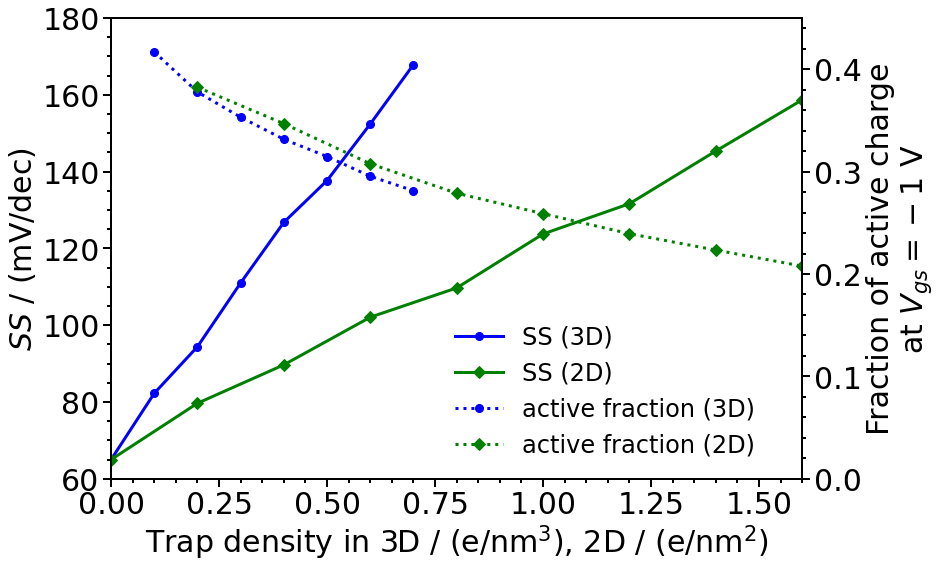

In [120]:
# Create the figure and axis
#fig, ax1 = plt.subplots(1, 1, figsize=(10, 7))  # Size of the figure
#fig = plt.figure(figsize=(12,8), constrained_layout=True)
fig = plt.figure(figsize=(12,8), constrained_layout=True)
ax1 = fig.add_axes([0.18,0.15,0.8,0.8])

custom_ls_pattern=(0, (3, 2, 1, 2, 1, 2))
fig.patch.set_facecolor('white')
ax1.patch.set_facecolor('white')
# Plotting for 3D and 2D data
x_lst = [rhop_3D, rhop_2D]
y_lst = [SS_3D, SS_2D]
label_lst = ['SS (3D)', 'SS (2D)']
color = ['b', 'g']
linestyle = [None, None]
markertype = ['o', 'D']
fillstyle = ['full', 'full']
linewidth = [3, 3]
markevery = [1, 1]

# Plot each line on the primary y-axis
for p in range(len(x_lst)):
    ax1.plot(x_lst[p], y_lst[p], color=color[p], linewidth=linewidth[p],
             linestyle=linestyle[p], marker=markertype[p], fillstyle=fillstyle[p],
             markevery=markevery[p], markersize=8, label=label_lst[p])

#ax1.legend(prop={'size': 24}, loc='best')

ax1.tick_params(which='minor', width=2, length=4, color='k')
ax1.tick_params(which='major', width=2, length=8, color='k')

ax1.set_xlim(0, 1.6)  # X-axis limit
ax1.set_ylim(60, 180)  # Y-axis limit for the primary y-axis (ax1)

ax1.set_xlabel(r'Trap density in 3D / (e/nm$^3$), 2D / (e/nm$^{2}$)', fontsize=30)
ax1.set_ylabel(r'$SS$ / (mV/dec)', fontsize=30)  # Primary y-axis label

for spine in ax1.spines.values():
    spine.set_linewidth(2)

ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())



ax2 = ax1.twinx()  # Create a second y-axis sharing the same x-axis
x2_lst = [rhop_3D[1:], rhop_2D[1:]]
y2_lst = [fractional_charge_3D[:,-6], fractional_charge_2D[:,-6]]  
linestyle2 = ['dotted', 'dotted']
label_lst2 = ['active fraction (3D)', 'active fraction (2D)']

#y2_lst = [np.insert(fractional_charge_3D[:,-1],0,1), np.insert(fractional_charge_2D[:,-1],0,1)]  

for p in range(len(x_lst)):
    ax2.plot(x2_lst[p], y2_lst[p], color=color[p], linewidth=linewidth[p],
             linestyle=linestyle2[p], marker=markertype[p], fillstyle=fillstyle[p],
             markevery=markevery[p], markersize=8, label=label_lst2[p], alpha=1)  # alpha for transparency

#ax2.legend(prop={'size': 24}, loc='best')

ax2.tick_params(which='minor', width=2, length=4, color='k')
ax2.tick_params(which='major', width=2, length=8, color='k')

ax2.set_ylim(0, 0.45)  
ax2.set_ylabel(r'Fraction of active charge'+'\n'+'at $V_{gs}=-1$ V', fontsize=30)  
    
for spine in ax2.spines.values():
    spine.set_linewidth(2)

ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())


#legends
# Get the handles and labels for both axes
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine the handles and labels
handles += handles2
labels += labels2

# Create a single legend for both axes with a fixed location
fig.legend(handles, labels, loc='lower right', prop={'size': 24},shadow=True, frameon=False,bbox_to_anchor=(0.95,0.15))


pltname = 'densityVar_3D_2D_SS_fraction.png'
plt.savefig(pltname, bbox_inches="tight", dpi='figure', format='png', pad_inches=0.1, 
            facecolor='white', edgecolor='auto')

plt.show()
